<a href="https://colab.research.google.com/github/msdrayton/ML_ECE517/blob/main/Intro_To_Algebra_and_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INTRODUCTION TO SOME BASIC MATHEMATICAL CONCEPTS NECESSARY IN MACHINE LEARNING**

<center>

*Young man, in mathematics you don't understand things. You just get used to them.* Attributed to John Von Neumann (1903-1957)


*In a way, mathematics is the only infinite human activity.* Paul Ërdos (1913-1996)

</center>

John von Neumann, who made foundational contributions to many areas of mathematics, quantum mechanics, economics, and computer science, and Paul Erdős, best known for his work in discrete mathematics and often described as the patron saint of mathematical collaboration, had two very different perspectives on mathematics. While von Neumann’s view was pragmatic, Erdős spoke of mathematics in more spiritual terms. From their quotes, we can learn that mathematics requires constant practice (to get used to it) and that we must continue learning throughout our lives.

In this review, we will cover a set of tools essential for the study of machine learning (though, of course, many other concepts are also necessary). We begin with vectors and matrices in Euclidean spaces. Next, we revisit the dot product operation and its key properties. We then introduce matrices more formally, along with their fundamental operations.

The following section focuses on computing the gradient of a matrix equation that will appear repeatedly in our course. We explain its derivation, supported by an example that highlights the importance of understanding the properties of matrix inverses.

After this, we move on to the basics of eigenanalysis, followed by the derivation of the pseudoinverse and the regularized pseudoinverse.

Finally, we conclude with an introduction to Lagrange optimization, which will play a central role in deriving Support Vector Machines.

# **Variables and Expressions**

A **variable** is a symbol (often $x,y,z$) representing an unknown or changeable value.  
An **algebraic expression** combines numbers, variables, and operations.

Example:
$$
3x + 7
$$
represents "three times $x$ plus seven".

# **Vectors**

A **vector** is an ordered list of numbers that can represent quantities such as position, velocity, or forces.

We can write:
$$
\mathbf{v} =
\begin{bmatrix}
v_1 \\
v_2 \\
v_3
\end{bmatrix}
\quad \text{or} \quad
(v_1, v_2, v_3)
$$


**Example:**  
If $\mathbf{a} = (2, 3)$ and $\mathbf{b} = (4, -1)$:
$$
\mathbf{a} + \mathbf{b} = (6, 2)
$$

In [ ]:
import numpy as np

# Define vectors
a = np.array([2, 3])
b = np.array([4, -1])

# Vector addition
a_plus_b = a + b
a_plus_b


# **The dot product**

The **dot product** of two vectors of the same dimension returns a scalar:

$$
\langle \mathbf{a},  \mathbf{b}\rangle = \mathbf{a}^\top  \mathbf{b} = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n
$$

where $\top$ is the transpose operator. This can be expressed as

$$
\mathbf{a}^\top  \mathbf{b} = \sum_{i=1}^D a_i b_i
$$

**Example:**
$$
(1, 2, 3) \cdot (4, 1, 2) = 4 + 2 + 6 = 12
$$

In standard matrix notation

$$
\mathbf{a}^\top  \mathbf{b} =
\begin{bmatrix}
1 &
2 &
3
\end{bmatrix}
\cdot
 \begin{bmatrix}
4 \\
1 \\
2\\
\end{bmatrix}
$$


Here we introduce an example of matrix multiplication, with only a row and a column, but we will see this operation in more detail later. Here we see that each element $i$ of the row is multiplied by the corresponding element $i$ of the column, and then the products are added together.  

In [ ]:
# Dot product example
a = np.array([1, 2, 3])
b = np.array([4, -1, 2])

dot_product = np.dot(a, b)
print(dot_product)


8


# **Euclidean norm**

The squared Euclidean norm of a vector is defined as the sum of the squares of its elements. If

$$
{\bf x}=(x_1, x_2, ... x_D)
$$
then
$$
\|{\bf x}\|^2 = \sum_{i=1}^D x_i^2
$$
is its squared Euclidean norm. By virtue of the definition of the dot product, this can be written as
$$
\|{\bf x}\|^2 = {\bf x}^\top {\bf x} = \begin{bmatrix}x_1&x_2& \cdots &x_D\end{bmatrix} \begin{bmatrix}x_1\\x_2\\ \vdots \\x_D\end{bmatrix} = \sum_{i=1}^D x_i^2
$$



# **The dot product-angle formula**
It can be proven (exercise) that
$$
\|{\bf c}\|^2 = \|{\bf a}\|^2 + \|{\bf b}\|^2 - 2  \|{\bf a}\| \|{\bf b}\| \cos C
$$
where $\theta$ is the angle between vectors ${\bf a}$ and ${\bf b}$. This is a generalization of the law of cosines.

<center>
<img src="https://drive.google.com/uc?export=view&id=1BG0uutAjIE3wdHspLc8o4CDCYhtXTuP1" alt="Triangle with vertices A, B, C and sides a, b, c" width="50%">
</center>

Since ${\bf c}= {\bf a} - {\bf b}$, then  
$$
\|{\bf a}-{\bf b}\|^2 = \|{\bf a}\|^2 + \|{\bf b}\|^2 - 2  \|{\bf a}\| \|{\bf b}\| \cos C
$$
and then, developing the difference at the left side of the equation
$$
\|{\bf a}\|^2+\|{\bf b}\|^2 - 2 {\bf a}^\top {\bf b}= \|{\bf a}\|^2 + \|{\bf b}\|^2 - 2  \|{\bf a}\| \|{\bf b}\| \cos \theta
$$
and, canceling terms
$$
 {\bf a}^\top {\bf b}=  \|{\bf a}\| \|{\bf b}\| \cos C
$$
which leads to

$$
\cos C = \frac{ {\bf a}^\top {\bf b}}{\|{\bf a}\| \|{\bf b}\|}
$$

In particular, if the angle $C$ is 90⁰, then the dot product is zero, and the maximum value of the dot product is achieved if the angle is zero degrees. Conversely, if the product between tweo non null vectors is zero, then they are perpendicular.  

In [ ]:
a = np.array([3, 3])
b = np.array([3,-3])
print(np.dot(a,b))

0


# **Matrices**

A **matrix** is a rectangular array of numbers arranged in rows and columns.

Example:
$$
{\bf A} =
\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}
$$
This is a $2 \times 3$ matrix. We usually denote this as $A \in {\mathbb R}^{2 \times 3}$


In [ ]:
# Define a matrix
A = np.array([[1, 2, 3],
              [4, 5, 6]])
A


array([[1, 2, 3],
       [4, 5, 6]])

# **Basic Matrix Manipulation**

### Addition:
Add corresponding entries (same size matrices):
$$
\begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix} +
\begin{bmatrix} 5 & 6 \\ 7 & 8 \end{bmatrix} =
\begin{bmatrix} 6 & 8 \\ 10 & 12 \end{bmatrix}
$$

### Scalar Multiplication:
Multiply every element by a number:
$$
3 \times
\begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix} =
\begin{bmatrix} 3 & 6 \\ 9 & 12 \end{bmatrix}
$$


# **Matrix Multiplication**

If ${\bf A}$ is $m \times n$ and ${\bf B}$ is $n \times p$,  then ${\bf A}{\bf B}$ is $m \times p$.  
Entry $(i, j)$ in ${\bf A}{\bf B}$ is the dot product of row $i$ of ${\bf A}$ and column $j$ of ${\bf B}$.

Example:
$$
\begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}
\begin{bmatrix} 5 & 6 \\ 7 & 8 \end{bmatrix} =
\begin{bmatrix} 19 & 22 \\ 43 & 50 \end{bmatrix}
$$


In [ ]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

product = np.dot(A, B)
product


array([[19, 22],
       [43, 50]])

# **Matrix Inversion**

For a square matrix ${\bf A}$, the inverse ${\bf A}^{-1}$ satisfies:
$$
{\bf A} {\bf A}^{-1} = I
$$
where $I$ is the identity matrix.

For:
$$
A = \begin{bmatrix} 4 & 7 \\ 2 & 6 \end{bmatrix}
$$
Determinant:
$$
(4)(6) - (7)(2) = 10
$$
Inverse:
$$
A^{-1} = \frac{1}{10} \begin{bmatrix} 6 & -7 \\ -2 & 4 \end{bmatrix}
$$


## Basic Properties of Matrix Inversion

Suppose ${\bf A}$is a square matrix and ${\bf A}^{-1}$ is its inverse. Then:



### 1. Definition of an Inverse
A square matrix ${\bf A}$ has an inverse ${\bf A}^{-1}$ if:
$
\mathbf{A} \mathbf{A}^{-1} = \mathbf{A}^{-1} \mathbf{A} = \mathbf{I}
$
where ${\bf I}$ is the identity matrix of the same size as ${\bf A}$.



### 2. Uniqueness
If ${\bf A}^{-1}$ exists, it is **unique**. There cannot be two different matrices that satisfy $\mathbf{A}\mathbf{X} = \mathbf{X}\mathbf{A} = \mathbf{I}$.



### 3. Inverse of a Product
If {\bf A} and {\bf B} are invertible matrices of the same size:
$
(\mathbf{A}\mathbf{B})^{-1} = \mathbf{B}^{-1} \mathbf{A}^{-1}
$
Notice the **reversal of order**.



### 4. Inverse of a Transpose
If {\bf A} is invertible:
$
(\mathbf{A}^T)^{-1} = (\mathbf{A}^{-1})^T
$



### 5. Inverse of a Scalar Multiple
For a nonzero scalar $k$:
$$
(k \mathbf{A})^{-1} = \frac{1}{k} \mathbf{A}^{-1}
$$



### 6. Inverse of an Inverse
$$
(\mathbf{A}^{-1})^{-1} = \mathbf{A}
$$



### 7. Inverse of a Power
If ${\bf A}$ is invertible and $n$ is a positive integer:
$$
(\mathbf{A}^n)^{-1} = (\mathbf{A}^{-1})^n
$$


### 8. Existence Condition
A square matrix ${\bf A}$ is invertible **if and only if** its determinant is nonzero:
$$
\det(\mathbf{A}) \neq 0
$$



### 9. Relation to Solving Linear Systems
If ${\bf A}$ is invertible, the linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$ has a unique solution:
$$
\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}
$$

In [ ]:
# Import numpy
import numpy as np

# Define two invertible matrices A and B
A = np.array([[2, 1],
              [3, 4]])
B = np.array([[1, 2],
              [0, 1]])

# Compute inverses
A_inv = np.linalg.inv(A)
B_inv = np.linalg.inv(B)

print("Matrix A:\n", A)
print("\nInverse of A:\n", A_inv)

print("\nMatrix B:\n", B)
print("\nInverse of B:\n", B_inv)

# 1. Inverse of a product
product_inv = np.linalg.inv(A @ B)
print("\n(A @ B)^-1:\n", product_inv)
print("B^-1 @ A^-1:\n", B_inv @ A_inv)

# 2. Inverse of a transpose
print("\n(A^T)^-1:\n", np.linalg.inv(A.T))
print("(A^-1)^T:\n", A_inv.T)

# 3. Inverse of a scalar multiple
k = 3
print("\n(kA)^-1:\n", np.linalg.inv(k*A))
print("1/k * A^-1:\n", (1/k)*A_inv)

# 4. Inverse of an inverse
print("\n(A^-1)^-1:\n", np.linalg.inv(A_inv))

# 5. Inverse of a power (A^2)^-1 = (A^-1)^2
A2 = A @ A
print("\n(A^2)^-1:\n", np.linalg.inv(A2))
print("(A^-1)^2:\n", A_inv @ A_inv)

# 6. Solve a linear system using inverse
b = np.array([5, 11])
x = A_inv @ b
print("\nSolution of Ax = b using A^-1:\n", x)
print("Check A @ x:\n", A @ x)


Matrix A:
 [[2 1]
 [3 4]]

Inverse of A:
 [[ 0.8 -0.2]
 [-0.6  0.4]]

Matrix B:
 [[1 2]
 [0 1]]

Inverse of B:
 [[ 1. -2.]
 [ 0.  1.]]

(A @ B)^-1:
 [[ 2.  -1. ]
 [-0.6  0.4]]
B^-1 @ A^-1:
 [[ 2.  -1. ]
 [-0.6  0.4]]

(A^T)^-1:
 [[ 0.8 -0.6]
 [-0.2  0.4]]
(A^-1)^T:
 [[ 0.8 -0.6]
 [-0.2  0.4]]

(kA)^-1:
 [[ 0.26666667 -0.06666667]
 [-0.2         0.13333333]]
1/k * A^-1:
 [[ 0.26666667 -0.06666667]
 [-0.2         0.13333333]]

(A^-1)^-1:
 [[2. 1.]
 [3. 4.]]

(A^2)^-1:
 [[ 0.76 -0.24]
 [-0.72  0.28]]
(A^-1)^2:
 [[ 0.76 -0.24]
 [-0.72  0.28]]

Solution of Ax = b using A^-1:
 [1.8 1.4]
Check A @ x:
 [ 5. 11.]


# **Gradient of $\mathbf{w}^\top\mathbf{p}$**
Given vectors $\mathbf{w},~\mathbf{p}\in \mathbb{R}^D$, compute $\nabla_w{\bf w}^\top{\bf p}$

The expression is a dot product and it can be written as
$$
f(\mathbf{w})=\sum_i w_i p_i
$$
The gradient is the vector of derivatives of this expression with respect each element $w_k$, with components  

$$
\frac{\partial f}{\partial w_k} =  p_k
$$
Hence
$$
\nabla_{\mathbf{w}} f = \mathbf{p}
$$
# **Gradient of ${\bf w}^\top{\bf R}{\bf w}$**
Given a vector ${\bf w}\in{\mathbb R}^D$ and a matrix ${\bf R}\in {\mathbb R}^{d\times D}$, compute $\nabla_w{\bf w}^\top{\bf R}{\bf w}$

The expression $f({\bf w})={\bf w}^\top{\bf R}{\bf w}$ is a scalar and it can be seen as the dot product of ${\bf w}$ by itself through matrix ${\bf R}$ provided the matrix is definite positive. First, we write the expression in terms of these elements
$$
f(\mathbf{w}) = \sum_{i,j} w_i R_{ij} w_j
$$

Then, we compute the derivative of the expression with respect to component  $w_k$:
$$
\frac{\partial f}{\partial w_k} = \sum_j R_{kj} w_j + \sum_i w_i R_{ik} = [\mathbf{R} \mathbf{w}]_k + [\mathbf{R}^\top \mathbf{w}]_k
$$
where operator $[{\bf v}]_k$ means "component $k$ of vector $\bf v$". Notice that the first summation is the dot product of row $k$ of matrix $\bf R$ with vector $\bf w$, and the second summation is the dot product of row $k$ of matrix ${\bf R}^\top$ with vector ${\bf w}$.

Now, if we construct a vector with all these components, we have
$$
\nabla_{\mathbf{w}} f = (\mathbf{R} + \mathbf{R}^\top) \mathbf{w}
$$
In case that the matrix is symmetric, then
$$
\nabla_{\mathbf{w}} f = 2\mathbf{R} \mathbf{w}
$$



# Example
Given a matrix ${\bf R} = {\bf X}{\bf X}^\top$ and a vector $\bf p$, where ${\bf X}\in {\mathbb R}^{D\times N}, N>D$ with randomly chosen column vectors, find the value of $\bf w$ that maximizes the funtion ${\bf w}^\top {\bf R}{\bf w}-2{\bf w}^\top {\bf p}+ {\bf y}^\top {\bf y}$

### Property 1
The expression    ${\bf w}^\top {\bf R}{\bf w} > 0$. Indeed, since $N>D$, then ${\bf R}$ is a square matrix with dimensions $D\times D$ with positive eigenvalues. By the Courant-Fischer Theorem (below), this inequality holds true.

### Property 2.
The Expression
$$
f({\bf w})={\bf w}^\top {\bf R}{\bf w}-2{\bf w}^\top {\bf p}
$$
Has a single minimum. The property can be proven by simply stating that the function has the form $f({\bf w})=\sum_{i,j}a_{i,j}w_i w_j+\sum_k b_k w_k$. Therefore,
$$
\lim_{w_l\rightarrow \pm \infty} f({\bf w})= +\infty
$$
Also, the function is quadratic in any direction. Therefore, it must contain a single minimum. Notice that we dropped ${\bf y}^\top{\bf y}$ because it is simply a constant.

### Property 3. Minimization
Since the function is continuously differentiable and it has a single minimum, it must be true that equation
$$
\nabla_{\bf w}f({\bf w})={\bf 0}
$$
has a single solution, and it corresponds to the value of ${\bf w}$ that produes the minimum value of the funtion.

### Solution

$$
\nabla_{\bf w}{\bf w}^\top {\bf R}{\bf w}-2{\bf w}^\top {\bf p}+{\bf y}^\top{\bf y}={\bf 0}
$$
$$
2{\bf R}{\bf w}-2{\bf p}={\bf 0}
$$
$$
{\bf R}{\bf w}={\bf p} \Rightarrow {\bf w}={\bf R}^{⁻1}{\bf p}
$$


In [ ]:
# Example. We generate a matrix A of 100 vectors of dimension 6 real random numbers and a vector p of dimension 6
import numpy as np

A=np.random.randn(6,100)
p=np.random.randn(6,1)

# Then, we compute matrix R=A*A^T. We compute its eigenvalues to show that they are all positive
R=np.dot(A,A.T)
L,Q=np.linalg.eig(R)
print("1. Eigenvalues of R: ", L )
#As an example we check that x^t R x is positive for any x
x=np.random.randn(6,1) # Any x
print("\n2. x^t R x is always positive: x.T R x =", x.T@R@x)

# Now we compute the solution to the problem min_w w^T R w -2w^t p as above
w=np.linalg.inv(R)@p
# Operator @ is equivalent to np.dot(·,·)
print("\n3. Optimal value of w: ", w)

#Now we confirm that the gradient 2Rw -2p is a vextor of zeros
print("\n4. The gradient is a vector of zeros: ")
print( 2*R@w-2*p)
print( "Well, almost zeros...")
#therefore, the minimum value of expression w.TRW-2w.Tp is
print("\n5. The minimum value of expression w.TRW-2w.Tp is")
print(w.T@R@w-2*w.T@p)
print("Check that this number is always lower than the one in (2.) above when you repeat the simulation")

print("\n6. Indeed, if you add even a small vector to the solution, the result is higher")
w2=w+0.01*np.random.randn(6,1) #Let us add a small random vector to the solution
print(w2.T@R@w2-2*w2.T@p)



1. Eigenvalues of R:  [139.81029484 124.8351807   74.28716927 110.63548123  98.78335422
  82.31771143]

2. x^t R x is always positive: x.T R x = [[785.19853313]]

3. Optimal value of w:  [[ 0.00936707]
 [ 0.00229425]
 [-0.00598858]
 [ 0.00103017]
 [-0.00527839]
 [ 0.00116002]]

4. The gradient is a vector of zeros: 
[[ 2.22044605e-16]
 [-3.33066907e-16]
 [ 2.22044605e-16]
 [ 5.55111512e-17]
 [ 0.00000000e+00]
 [ 1.38777878e-17]]
Well, almost zeros...

5. The minimum value of expression w.TRW-2w.Tp is
[[-0.01583058]]
Check that this number is always lower than the one in (2.) above when you repeat the simulation

6. Indeed, if you add even a small vector to the solution, the result is higher
[[0.08070707]]


### Why $\bf R$ has only positive eigenvalues>? Is that true?

Well... not exactly. We assumed that ${\bf R}={\bf A}{\bf A}^\top$. Then,
$$
{\bf x}^\top{\bf R}{\bf x}={\bf x}{\bf A}{\bf A}^\top{\bf x} = \|{\bf A}^\top{\bf x}\|^2
$$
Thus, the operation ${\bf x}^\top{\bf R}{\bf x}$ is the squared norm of vector ${\bf v}= {\bf A}^\top{\bf x}$. ${\bf A}$ is a collection of $N$ vectors of dfimension $D$. If these vectors _span_ space $\mathbb{R}^D$, then no vector ${\bf x}$ is orthogonal to all vectors in ${\bf A}$, and therefore vector ${\bf A}^\top{\bf x}$, which is the vector of dot products between the vectors in ${\bf A}$ and ${\bf x}$, will contain at least one non null element.

If the vectors contained in $\bf A$ do not span the space (i.e, the number of linearly independent vectors inside the matrix is less than $D$), then the product ${\bf A}^\top{\bf x}=0$ for some vector ${\bf x}\in {\mathbb R}^D$.

So we do not need a coillection of $N$ _distinct_ vectors, but we actually need a collection of $N$ vectors where at least $D$ are linearly independent.

---

In the simulation, we generate $N=100$ random vectors expressed with $64$ bits. For the first D=6 vectors, the probability that two are dependent is
$$
P(\text{two dependent vectors})=\mathcal{O}(D(D-1)2^{64*(1-D)})=\mathcal{O}(10^{-96})
$$
so, almost impossible. If $N$ and $D$ are similar numbers, but still $N>D$, it is possible that two vectors are very similar, and therefore it is possible that  $\|{\bf A}^\top{\bf x}\|^2$ is very small for some ${\bf x}$. This means that at least one eigenvalue of $\bf R$ is very small (i.e it is represented with a subset of the least significant bits). This will produce numerical errors when we invert the matrix. Then we need to regularize  matrix ${\bf R}$ (see Section **Regularized Pseudoniverse** below).



# **Eigenvectors and Eigenvalues**



## 1. Definition

For a square matrix ${\bf A}\in  \mathbb{R}^{N\times N}$, a **non-zero vector** ${\bf q}\in \mathbb{R}^N$ is an **eigenvector** of $\bf A$ if:

$$
\mathbf{A} \mathbf{q} = \lambda \mathbf{q}, \quad \mathbf{q} \neq 0
$$

- ${\bf q}$ = eigenvector, where ${\bf q}_i^\top{\bf q}_j=0$, ${\bf q}_i^\top{\bf q}_i=1$, this is, the eigenvectors are orthogonal and normal (orthonormal).   
- $\lambda$ = eigenvalue  
- ${\bf Aq}$ = linear transformation of $\bf q$

Eigenvectors do not change direction under $\bf A$; they are only scaled by $\lambda$.

Since ${\bf A}{\bf q}=\lambda {\bf q}$, then

$$
{\bf A}{\bf Q}={\bf Q} {\boldsymbol \Lambda}
$$
where ${\bf Q}, {\boldsymbol \lambda}$ are the matrix of eigenvectors and the diagonal matrix of eigenvalues respectively. Then, postmultuplying by the inverse of the eigenvector matrix gives the expression

$$
{\bf A} = {\bf Q}{\boldsymbol \Lambda}{\bf Q}^{-1}
$$
 However, ${\bf Q}$ is a matrix with orthonormal vectors, then ${\bf Q}^\top {\bf Q}={\bf I}$ and hence ${\bf Q}^\top={\bf Q}^{-1}$. Therefore

$$
{\bf A} = {\bf Q}{\boldsymbol \Lambda}{\bf Q}^\top
$$

## 2. Finding Eigenvalues and Eigenvectors

### Eigenvalues
Solve the **characteristic equation**:

$$
\det(\mathbf{A} - \lambda \mathbf{I}) = 0
$$

### Eigenvectors
For each eigenvalue λ, solve:

$$
(\mathbf{A} - \lambda \mathbf{I}) \mathbf{v} = 0
$$


## 3. Properties

### Eigenvalues
1. Sum of eigenvalues = $\text{trace}({\bf A})$  
2. Product of eigenvalues = $\text{determinant}({\bf A})$
3. Eigenvalues of triangular matrix = diagonal elements  
4. Eigenvalues of ${\bf A}$ : $\lambda_k$, eigenvalues of ${\bf A}$ : $\frac{1}{\lambda_k}$  
5. Symmetric matrices → eigenvalues are **real**

### Eigenvectors
1. Eigenvectors corresponding to **distinct eigenvalues** are **linearly independent**  
2. Symmetric matrices → eigenvectors are **orthogonal**  





In [ ]:
import numpy as np
B=np.random.randn(10,6)
A1=np.dot(B.T,B)
print('Matrix dimensions', A1.shape)
L,Q=np.linalg.eig(A1)
print('Eigenvalues', np.round(L,3))

A2=np.dot(B,B.T)
L,Q=np.linalg.eig(A2)
print('Matrix dimensions',A2.shape)
print('Eigenvalues', np.real(np.round(L,3)))


Matrix dimensions (6, 6)
Eigenvalues [33.103 18.802  0.728  1.733  7.095  6.359]
Matrix dimensions (10, 10)
Eigenvalues [33.103 18.802  7.095  6.359  1.733  0.728  0.     0.    -0.    -0.   ]


# **The Courant-Fischer theorem**
Let ${\bf A} \in \mathbb{R}^{n \times n}$ be symmetric (or Hermitian), and let its eigenvalues be ordered as
$$
\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n.
$$
Then, for each $k = 1, \dots, n$, the following variational characterizations hold:
$$
\lambda_k \;=\; \max_{\substack{S \subset \mathbb{R}^n \\ \dim(S) = k}} \;
\min_{\substack{{\bf x} \in S \\ x \neq 0}} \;
\frac{{\bf x}^\top {\bf A} {\bf x}}{{\bf x}^\top {\bf x}},
$$
and equivalently,
$$
\lambda_k \;=\; \min_{\substack{S \subset \mathbb{R}^n \\ \dim(S) = n-k+1}} \;
\max_{\substack{{\bf x} \in S \\ {\bf x} \neq 0}} \;
\frac{{\bf x}^\top {\bf A} {\bf x}}{{\bf x}^\top {\bf x}}.
$$

## Explanation
The matrix is symmetric, so it has a set of $n$ **real** eigenvalues. Let us choose eigenvalue $\lambda_k$ and any subspace $S$ inside the space ${\mathbb R}^N$. The minimum
$$
\min_{\substack{x \in S \\ x \neq 0}} \frac{x^\top {\bf A} x}{x^\top x}
$$    
of the first equation expresses the vector ${\bf x}$ that produces the minimum _Raileigh quutient_ for any subspace $S$. Then, with the maximum in the formula, choose the subspace $S$ that maximizes this minimum, and this is equal to eigenvalue $\lambda_k$.
## Corollary
For a symmetric matrix ${\bf A}$,
 ${\bf x}^\top{\bf A}{\bf x}>0$ for any vector ${\bf x}\neq {\bf 0}$ if and only all eigenvalues of ${\bf A}$ are real and positive.



# **Autocorrelation and Gram matrices**
## Autocorrelation matrix
Given a random process ${\bf x}_n$, $1 \leq n \leq N$, itys autocorrelation matrix is defined as the matrix $\bf R$ with components $[{\bf R}]_{i,j}=\mathbb{E}(x_{i,n},x_{j,n})$

The autocorrelation matrix can be computed as
$$
{\bf R}= \mathbb{E}\left({\bf x}_n {\bf x}_n^\top\right)
$$
Indeed, the outer product ${\bf x}_n {\bf x}_n^\top$ has components $x_{i,n},x_{j,n}$, hence the expression is valid.

A _sample estimation_ of this expectation can thus be computed as

$$
{\bf R}\approx \frac{1}{N}\sum_{n=1}^N {\bf x}_n {\bf x}_n^\top
$$
From the Weak Law of Large Numbers, it can be said that
$$
{\bf R}= \lim_{n\rightarrow \infty} \frac{1}{N}\sum_{n=1}^N  {\bf x}_n {\bf x}_n^\top
$$

By the definition of the sample estimation, it can be seen that
$$
\hat{\bf R} = \frac{1}{N}\sum_{n=1}^N {\bf x}_n {\bf x}_n^\top = \frac{1}{N}\mathbf{X}\mathbf{X}^\top
$$
where
$$
\mathbf{X}=\left[\mathbf{x}_1,\cdots ,\mathbf{x}_N \right]
$$
To prove it, we just need to notice that
$$
[\mathbf{R}]_{i,j}=\sum_{n=1}^N x_{i,n}x_{j,n}
$$
wich corresponds to the dot product of row $i$ of matrix $\mathbf{X}$ with column $j$ of matrix $\mathbf{X}^\top$.

##Gram matrix

The gram matrix $\mathbf K$ of process $\mathbf{x}_n$ is the matrix containing dot products $\mathbf{x}_n^\top \mathbf{x}_m$. Therefore, this matrix can be computed as
$$
\mathbf{K}=\mathbf{X}^\top \mathbf{X}
$$


## Equivalence of both matrices
$$
\mathbf{X} \mathbf{X}^\top \mathbf{q}_i = \lambda_i \mathbf{q}_i, \quad i = 1,\dots,D
$$
By premultiplication of this expression by $\mathbf{X}^\top$
$$
\mathbf{X}^\top\mathbf{X} \mathbf{X}^\top \mathbf{q}_i = \lambda_i \mathbf{X}^\top\mathbf{q}_i, \quad i = 1,\dots,D
$$
Then the eigenvalues of $\mathbf{X}^\top \mathbf{X}$  are $\lambda_i$ and eigenvectors:

$$
\mathbf{u}_i \propto  \mathbf{X}^\top \mathbf{q}_i
$$
Since the eigenvectors must have unitary norm
$$
\mathbf{u}_i =\frac{1}{\sqrt{\mathbf{q}_i^\top\mathbf{X}\mathbf{X}^\top\mathbf{q}_i}} \mathbf{X}^\top \mathbf{q}_i
$$
where
$$
\mathbf{q}_i^\top\mathbf{X}\mathbf{X}^\top\mathbf{q}_i=\lambda_i\mathbf{q}^\top\mathbf{q}_i=\lambda_i
$$
This is,
$$
\mathbf{u}_i =\frac{1}{\lambda_i} \mathbf{X}^\top \mathbf{q}_i
$$

Additionally, for $ D < N, \mathbf{X}^\top \mathbf{X}$ has $N-D$  zero eigenvalues.


# **Pseudoinverse**

Assume a rectangular matrix $\mathbf{A} \in \mathbb{R}^{M\times N}$. The pseudoinverse matrix $\mathbf{A}^\dagger\in \mathbb{R}^{N\times M}$ is the matrix that satisfies the equality
$$
\mathbf{A}\mathbf{A}^\dagger = \mathbf{I}_{M}
$$

By manipulation of the equation, the solution for $\mathbf{A}^\dagger$ can be found. First, we premultiply by $\mathbf{A}^\top$

$$
\mathbf{A}^\top\mathbf{A}\mathbf{A}^\dagger = \mathbf{A}^\top
$$
where we used the fact that $\mathbf{A}^\top \mathbf{I}_{M}=\mathbf{A}^\top$. Then, we premultiply the equation by $\left(\mathbf{A}^\top\mathbf{A}\right)^{-1}$

$$
\mathbf{A}^\dagger =\left(\mathbf{A}^\top\mathbf{A}\right)^{-1} \mathbf{A}^\top
$$
which leads to the solution, where we used $\left(\mathbf{A}^\top\mathbf{A}\right)^{-1}\mathbf{A}^\top\mathbf{A}=\mathbf{I}_N$ and $\mathbf{A}=\mathbf{I}_N\mathbf{A}^\dagger=\mathbf{A}^\dagger$.


If such solution exists, it is easy to prove that it is a pseudoniverse. Indeed, the equality
$$
\mathbf{A}\left(\mathbf{A}^\top\mathbf{A}\right)^{-1} \mathbf{A}^\top= \mathbf{I}_M
$$
can be proven by post-multiplying the expression by $\mathbf{A}$
$$
\mathbf{A}\left(\mathbf{A}^\top\mathbf{A}\right)^{-1} \mathbf{A}^\top\mathbf{A}= \mathbf{I}_M \mathbf{A}=\mathbf{A}
$$
Since $\left(\mathbf{A}^\top\mathbf{A}\right)^{-1} \mathbf{A}^\top\mathbf{A}=\mathbf{I}_N$, this leads to the equality ${\bf A}={\bf A}$.

For the solution to exist, the inverse of the square matrix ${\bf A}^\top{\bf A}$ must exist.

# Existence of the pseudoinverse

Let ${\bf A} \in \mathbb{R}^{M\times N}$. We first prove that ${\bf A}^{\mathsf T}{\bf A}$ is symmetric positive semidefinite.

1) Symmetry.
$$
({\bf A}^{\mathsf T}{\bf A})^{\mathsf T} = {\bf A}^{\mathsf T}({\bf A}^{\mathsf T})^{\mathsf T} = {\bf A}^{\mathsf T}{\bf A},
$$
so ${\bf A}^{\mathsf T}{\bf A}$ is symmetric.

2) Nonnegativity of eigenvalues.
Because ${\bf A}^{\mathsf T}{\bf A}$ is symmetric, it is diagonalizable with an orthonormal basis of eigenvectors.
Let ${\bf q}\neq {\bf 0}$ be an eigenvector with eigenvalue $\lambda$, so
$$
{\bf A}^{\mathsf T}{\bf A} {\bf q} = \lambda {\bf q}.
$$
Left-multiplying  by ${\bf q}^{\mathsf T}$ gives
$$
{\bf q}^{\mathsf T}{\bf A}^{\mathsf T}{\bf A} {\bf q} = \lambda\, {\bf q}^{\mathsf T}{\bf q}.
$$
But ${\bf q}^{\mathsf T}{\bf A}^{\mathsf T}{\bf A} {\bf q} = ({\bf A} {\bf q})^{\mathsf T}({\bf A} {\bf q})=\|{\bf A} {\bf q}\|_2^2\ge 0$ and ${\bf q}^{\mathsf T}{\bf q}=\|{\bf q}\|_2^2=1$.

Hence
$$
\lambda = \|{\bf A} {\bf q}\|_2^2\;\ge\;0
$$
Therefore every eigenvalue of ${\bf A}^{\mathsf T}{\bf A}$ is nonnegative.

As shown in the previous cell, the number of non null eigenvalues is equal to $\min(M,N)$, and there will be $\|M-N\|$ null eigenvalues.

Next, we compute the eigendecomposition of the inverse matrix. Define $\mathbf{R}={\bf A}^{\mathsf T}{\bf A} \in \mathbb{R}^{N \times N}$. This matrix is square and it can be decomposed into eigenvectors and eigenvalues as $\mathbf{R}={\bf Q}{\boldsymbol \Lambda}{\bf Q}^\top$. Its inverse is

$$
\left({\bf A}^{\mathsf T}{\bf A}\right)^{-1}=\left({\bf Q}{\boldsymbol \Lambda}{\bf Q}^\top\right)^{-1} = ({\bf Q}^\top)^{-1}{\boldsymbol \Lambda}^{-1}{\bf Q}^{-1}={\bf Q}{\boldsymbol \Lambda}^{-1}{\bf Q}^\top
$$
where we used the facts $({\bf ABC})^{-1}={\bf C}^{-1}{\bf B}^{-1}{\bf A}^{-1}$ and ${\bf Q}^\top={\bf Q}^{-1}$.

Thus, inverting matrix ${\bf A}^{\mathsf T}{\bf A}$ involves inverting the diagonal matrix of eigenvalues wich, in turn, is achieved by inverting each one of the elements of this diagonal matrix. If all values are positive, the inverse exists. If some values are zero, then the inverse does not exist. Therefore, the pseudoinverse of ${\bf A}$ exists if and only if $N \leq M$.

## Regularized pseudoinverse

In the case $N\geq M$ there will be $M-N$ null eigenvectors. We camn regularize the pseudoinverse with the addition of a small diagonal term, this is:
$$
{\bf A}^\dagger = \left( \mathbf{A}^\top \mathbf{A} + \gamma {\bf I} \right)^{-1} \mathbf{A}^\top
$$
where $\gamma>0$ is a small scalar, which ensures the existence of the inverse. Indeed,
$$
\mathbf{A}^\top \mathbf{A} + \gamma {\bf I} = {\bf Q} {\boldsymbol \Lambda}{\bf Q}^\top  + \gamma {\bf Q} {\bf I}{\bf Q}^\top
$$  
where we use the fact that ${\bf Q} {\bf I}{\bf Q}^\top = {\bf I}$

Now, by regrouping terms
$$
\mathbf{A}^\top \mathbf{A} + \gamma {\bf I} = {\bf Q} ({\boldsymbol \Lambda}+\gamma {\bf I}){\bf Q}^\top   
$$
which is a matrix whose minimum valued eigenvalue is $\gamma$, and hence it can be inverted. If $\gamma$ is small, this guarantees that  $\mathbf{A}^\top \mathbf{A} + \gamma {\bf I} \approx \mathbf{A}^\top \mathbf{A} $.

# **Lagrange Optimization**


## Introduction
We want to optimize a function (maximize or minimize) subject to equality constraints.

- Objective: $ f(x_1, \dots, x_n) $
- Constraint(s): $ g_i(x_1, \dots, x_n) = 0 $

The method introduces **Lagrange multipliers** so that:

$$
\nabla f(x^*) = \sum_{i} \lambda_i \nabla g_i(x^*)
$$

<center>
<img src="https://drive.google.com/uc?export=view&id=12wSyguUAzzDvszwpRXVWyebzzAqJZK_2" alt="Example of optimization with constraints" width="50%">
</center>
## Example Problem

We want to maximize:

$$
 f(x,y) = xy
$$

subject to the constraint:

$$
 g(x,y) = x^2 + y^2 - 1 = 0
$$

This means we are finding extrema of $xy$ on the unit circle.

---

## Python Setup



In [ ]:
import sympy as sp

# Define variables
x, y, λ = sp.symbols('x y λ')

# Objective function
def f(x, y):
    return x*y

# Constraint
def g(x, y):
    return x**2 + y**2 - 1

# Build Lagrangian
L = f(x,y) + λ*g(x,y)

# Partial derivatives
eq1 = sp.diff(L, x)
eq2 = sp.diff(L, y)
eq3 = sp.diff(L, λ)

# Solve equations
solutions = sp.solve([eq1, eq2, eq3], [x, y, λ], dict=True)
solutions

[{x: -sqrt(2)/2, y: -sqrt(2)/2, λ: -1/2},
 {x: -sqrt(2)/2, y: sqrt(2)/2, λ: 1/2},
 {x: sqrt(2)/2, y: -sqrt(2)/2, λ: 1/2},
 {x: sqrt(2)/2, y: sqrt(2)/2, λ: -1/2}]



---

## Analytical Explanation
1. Build the **Lagrangian**:
   $$
   \mathcal{L}(x,y,\lambda) = xy + \lambda(x^2+y^2-1)
   $$

2. Derivatives:
   - $\frac{\partial L}{\partial x} = y + 2\lambda x = 0 $
   - $ \frac{\partial L}{\partial y} = x + 2\lambda y = 0 $
   - $ \frac{\partial L}{\partial \lambda} = x^2+y^2-1 = 0 $

3. Solve system → critical points.

---

## Evaluate Solutions


In [ ]:

# Evaluate objective function at each solution
results = [(sol, f(sol[x], sol[y])) for sol in solutions]
results


[({x: -sqrt(2)/2, y: -sqrt(2)/2, λ: -1/2}, 1/2),
 ({x: -sqrt(2)/2, y: sqrt(2)/2, λ: 1/2}, -1/2),
 ({x: sqrt(2)/2, y: -sqrt(2)/2, λ: 1/2}, -1/2),
 ({x: sqrt(2)/2, y: sqrt(2)/2, λ: -1/2}, 1/2)]



Expected results:
- Maximum: $ f = 1/2 $
- Minimum: $ f = -1/2 $

---

## Visualization

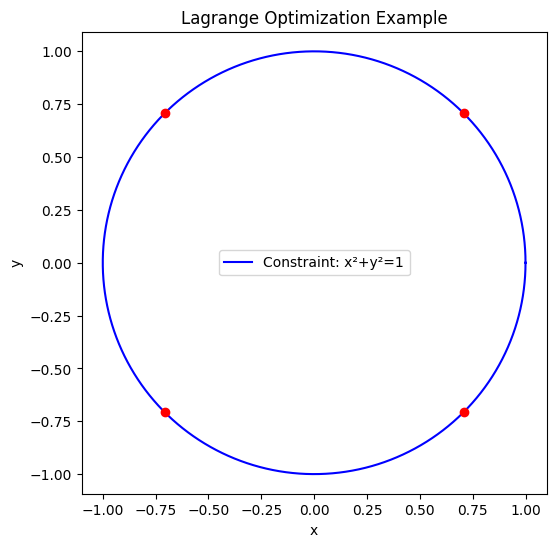

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the constraint (unit circle)
theta = np.linspace(0, 2*np.pi, 200)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

plt.figure(figsize=(6,6))
plt.plot(x_circle, y_circle, 'b', label='Constraint: x²+y²=1')

# Plot solutions
for sol in solutions:
    plt.plot(float(sol[x]), float(sol[y]), 'ro')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Lagrange Optimization Example')
plt.axis('equal')
plt.show()



---

## 3D representation

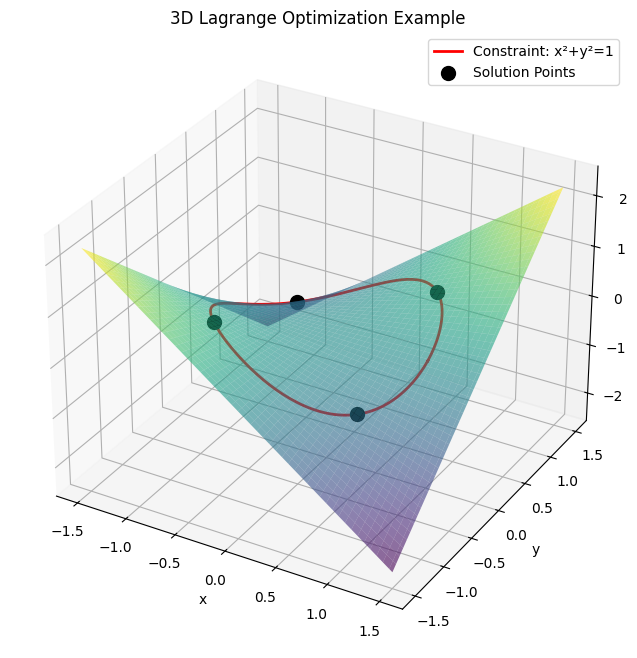

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Define the objective function and constraint in terms of numpy arrays for plotting
def f_np(x, y):
    return x * y

def g_np(x, y):
    return x**2 + y**2 - 1

# Create a grid for plotting the objective function
x_vals = np.linspace(-1.5, 1.5, 100)
y_vals = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_np(X, Y)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface of the objective function
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# Plot the constraint (unit circle) in 3D, lifted to the surface of the objective function
theta = np.linspace(0, 2*np.pi, 200)
x_circle_3d = np.cos(theta)
y_circle_3d = np.sin(theta)
z_circle_3d = f_np(x_circle_3d, y_circle_3d) # Evaluate f(x,y) on the circle

ax.plot(x_circle_3d, y_circle_3d, z_circle_3d, color='r', linewidth=2, label='Constraint: x²+y²=1')

# Plot the solution points
# Reuse the 'solutions' variable from the previous cell
for sol in solutions:
    sol_x = float(sol[x])
    sol_y = float(sol[y])
    sol_z = f_np(sol_x, sol_y)
    ax.scatter(sol_x, sol_y, sol_z, color='k', s=100, marker='o', label='Solution Points' if sol == solutions[0] else "")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('3D Lagrange Optimization Example')
ax.legend()
plt.show()



# **Generalization to Several Constraints & KKT Conditions**

This section extends the method of Lagrange multipliers to **multiple equality and inequality constraints** and presents the **Karush–Kuhn–Tucker (KKT)** conditions. All math is paired with runnable Python/SymPy code.

### 1 General Multi-Constraint Setup
We want to optimize
$$
\min_{x\in\mathbb{R}^n} f(x) \quad \text{s.t.}\quad h_i(x)=0,\; i=1,\dots,m \; (m\le n).
$$
Define the **Lagrangian**
$$
\mathcal{L}(x,\lambda) = f(x) + \sum_{i=1}^m \lambda_i\,h_i(x), \quad \lambda\in\mathbb{R}^m.
$$
**First-order necessary conditions (FONC)** at a candidate optimum $(x^*,\lambda^*)$:
- **Stationarity:** $\nabla_x \mathcal{L}(x^*,\lambda^*) = \nabla f(x^*) + \sum_{i=1}^m \lambda_i^*\,\nabla h_i(x^*) = 0.$
- **Primal feasibility:** $h_i(x^*)=0$ for all $i$.
- **Constraint qualification (CQ):** Typically we assume **LICQ** (the gradients $\{\nabla h_i(x^*$}$ are linearly independent), which guarantees the existence of multipliers.

**Second-order conditions (SOC)** (under LICQ): Let
$W=\nabla^2_{xx}\mathcal{L}(x^*,\lambda^*)$. Consider the **tangent space**
$$T=\{d\in\mathbb{R}^n: \nabla h_i(x^*)^\top d = 0,\; i=1,\dots,m\}.
$$
- **SOSC for a strict local minimum:** $d^\top W d > 0$ for all nonzero $d\in T$.
- (Equivalently via a **bordered Hessian** test.)

### Code: Multiple Equality Constraints (symbolic)
Below we solve a small example with **two equality constraints**.

> Example: minimize $f(x,y,z)=x^2+y^2+z^2$ subject to $h_1:x+y+z-1=0$ and $h_2:x-y=0$.

```python
import sympy as sp

# Variables and multipliers
x, y, z = sp.symbols('x y z', real=True)
l1, l2 = sp.symbols('l1 l2', real=True)

# Objective and constraints
f = x**2 + y**2 + z**2
h1 = x + y + z - 1
h2 = x - y

# Lagrangian
L = f + l1*h1 + l2*h2

# Stationarity conditions
K1 = sp.diff(L, x)  # 2x + l1 + l2 = 0
K2 = sp.diff(L, y)  # 2y + l1 - l2 = 0
K3 = sp.diff(L, z)  # 2z + l1 = 0

# Primal feasibility
K4 = h1             # x + y + z - 1 = 0
K5 = h2             # x - y = 0

sol_eq = sp.solve([K1, K2, K3, K4, K5], [x, y, z, l1, l2], dict=True)
sol_eq
```

We can also verify the **SOSC** by checking the


# **Generalization of Lagrange Optimization with Multiple Constraints and Dual Solutions**
This Google Colab notebook explains **Lagrange optimization**, its generalization to multiple constraints, **KKT conditions**, and the interpretation of **dual solutions**.



## Problem Setup
We want to optimize a function:

$$
\text{maximize/minimize } f(x_1, \dots, x_n)
$$

subject to:
- Equality constraints: $ g_i(x) = 0, \quad i=1,\dots,m $
- Inequality constraints: $ h_j(x) \leq 0, \quad j=1,\dots,p $



## Lagrangian with Multiple Constraints
The **generalized Lagrangian** is:

$$
\mathcal{L}(x, \lambda, \mu) = f(x) + \sum_{i=1}^m \lambda_i g_i(x) + \sum_{j=1}^p \mu_j h_j(x)
$$

- $ \lambda_i $ are multipliers for equality constraints.
- $ \mu_j $ are multipliers for inequality constraints.

The multipliers $\lambda_i, \mu_j$ are also called **dual variables**, and the **dual function** is defined as:

$$
q(\lambda, \mu) = \inf_x \mathcal{L}(x, \lambda, \mu)
$$

Maximizing the dual function over $\lambda$ and $\mu \ge 0$ gives the **dual problem**, which provides a **lower bound** (for minimization problems) to the primal optimal value.


##  KKT Conditions
For a local optimum $x^*$, the **KKT conditions** are:

1. **Stationarity**
   $$
   \nabla f(x^*) + \sum_{i=1}^m \lambda_i \nabla g_i(x^*) + \sum_{j=1}^p \mu_j \nabla h_j(x^*) = 0
   $$

2. **Primal feasibility**
   $$
   g_i(x^*) = 0, \quad h_j(x^*) \le 0
   $$

3. **Dual feasibility**
   $$
   \mu_j \ge 0
   $$

4. **Complementary slackness**
   $$
   \mu_j h_j(x^*) = 0
   $$

Dual solutions $(\lambda^*, \mu^*$) correspond to the multipliers at the optimum. They **measure the sensitivity** of the objective function to perturbations in the constraints:
- For equality constraints: increasing $g_i$ by a small amount changes the optimal value approximately by $\lambda_i^*\delta g_i$.
- For inequality constraints: if active, $\mu_j^*$ measures how much the objective would improve if the constraint were relaxed.



## Example with Dual Solution Interpretation
**Problem:**

Maximize:
$$
 f(x,y) = x + y
$$

subject to:
$$
 g(x,y) = x^2 + y^2 - 1 = 0 \quad \text{(unit circle)}
$$

$$
 h(x,y) = x \ge 0 \quad \text{(inequality)}
$$

**Dual interpretation:**
- $\lambda^*$ shows how much increasing the radius of the circle changes the maximum of $x+y$.
- $\mu^*$ shows the sensitivity to relaxing $x \ge 0$.



## Python Implementation
```python
import sympy as sp

# Variables
x, y = sp.symbols('x y')
λ, μ = sp.symbols('λ μ')

# Objective
f = x + y

# Constraints
g = x**2 + y**2 - 1
h = -x  # inequality x>=0

# Lagrangian
L = f + λ*g + μ*h

# Stationarity
eq1 = sp.diff(L, x)
eq2 = sp.diff(L, y)

# Solve for primal variables and equality multiplier
solutions = sp.solve([eq1, eq2, g], [x, y, λ], dict=True)
solutions
```



## Checking KKT and Dual Solutions
```python
valid_solutions = []
for sol in solutions:
    h_val = h.subs(sol)
    if h_val < 0:
        μ_val = 0  # inactive constraint
    else:
        μ_val = sp.symbols('μ')  # may be positive
    valid_solutions.append((sol, h_val, μ_val))

valid_solutions
```

**Interpretation:**
- $λ^*$ is the dual variable for the equality constraint.
- $μ^*$ is the dual variable for the inequality constraint.
- Nonzero dual variables indicate active constraints influencing the optimal objective.



## Summary
- Dual solutions (Lagrange multipliers) quantify the sensitivity of the optimal value to constraint changes.
- KKT conditions determine valid primal-dual pairs.
- Active constraints correspond to nonzero dual variables; inactive constraints have zero duals.
- Understanding dual solutions is critical in **sensitivity analysis**, **resource allocation**, and **machine learning** (e.g., SVMs).
